# Statistics II Practice – Project Cycle 1
Exploratory Data Analysis Workflow (Diabetes.csv)

## Overview

This notebook is the required template for **Project Cycle 1**.

You must complete the **TO DO** parts and write interpretations.
- Use **matplotlib** for plotting in required sections.
- Keep the notebook **runnable from top to bottom**.
- Work as a **group** and make sure every member understands the notebook.

Project question (Cycle 1):
**Which characteristics appear related to diabetes (Outcome) in this dataset?**


## 0. Setup

In [116]:
import numpy as np # Import numpy for numerical operations / 載入 numpy 套件，用於處理數值與陣列運算
import pandas as pd # Import pandas for data manipulation / 載入 pandas 套件，用於處理表格化資料
import matplotlib.pyplot as plt # Import pyplot for data visualization / 載入 matplotlib.pyplot 套件，用於繪製圖表

# USE YOUR GROUP NUMBER AS THE SEED
SEED = 12  # Set random seed to group number 12 for reproducible results / 將隨機種子設定為第 12 組，確保每次抽樣結果一致
np.random.seed(SEED) # Apply the random seed to numpy / 將設定好的種子應用到 numpy 系統中

## 1. Load and Inspect the Dataset

Required file: `Diabetes.csv`

TO DO:
1) Load the CSV into a DataFrame named `df`  
2) Display the first 5 rows  
3) Report: number of rows, number of columns  
4) Check data types  


In [119]:
# Load dataset using pandas read_csv function / 使用 pandas 的 read_csv 函數讀取 CSV 資料集檔案
df = pd.read_csv("Diabetes.csv")

# Preview the first 5 rows of the DataFrame / 預覽資料表 (DataFrame) 的前 5 筆資料
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [121]:
# Show dataset shape: returns a tuple of (number of rows, number of columns) / 顯示資料集的形狀：會回傳一個包含 (資料列數, 欄位數) 的元組
df.shape

(768, 9)

In [123]:
# Inspect column data types and the number of non-null values / 檢查各欄位的資料型態，以及非空值 (non-null) 的數量
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Interpretation (3–5 lines):
- How many observations and variables?
- What is the outcome variable?
- What types of variables do you see (continuous vs discrete/binary)?


The dataset consists of 768 observations (rows) and 9 variables (columns). The outcome variable is Outcome, which indicates whether a patient has diabetes (0 for non-diabetic, 1 for diabetic). The variables include continuous variables (such as Glucose, BloodPressure, SkinThickness, Insulin, BMI, and DiabetesPedigreeFunction) and discrete/binary variables (such as Pregnancies, Age, and Outcome).

## 2. Data Quality Checks

TO DO:
1) Summary statistics (`describe`)  
2) Missing value check  
3) Identify suspicious values (e.g., zeros where impossible/unlikely)  


In [128]:
# Generate descriptive statistics (mean, min, max, quartiles) for numeric columns / 產生數值欄位的敘述性統計摘要 (包含平均數、最小值、最大值、四分位數等)
summary = df.describe()
summary # Display the summary table / 顯示摘要表格

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [130]:
# Count the number of missing (NaN/null) values in each column / 計算每個欄位中缺失值 (NaN 或 null) 的總數量
missing_counts = df.isna().sum()
missing_counts # Display the missing value counts / 顯示缺失值統計結果

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [132]:
# Define a list of variables where a value of 0 is medically suspicious / 定義一個變數清單，這些變數數值為 0 在醫學上是不合理/可疑的
vars_to_check = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# Filter the dataframe where these variables equal 0, then sum the occurrences / 篩選出這些變數數值等於 0 的資料，並加總其發生的次數
zero_counts = (df[vars_to_check]==0).sum()   
zero_counts # Display the count of zero values for each specified variable / 顯示這些特定變數中 0 值的數量

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Interpretation (5–8 lines):
- Are there missing values?
- Which variables have suspicious values?
- What might those suspicious values mean for analysis (e.g., missing coded as 0)?


According to the isna().sum() output, there appear to be no standard missing values (NaN). However, several variables contain medically suspicious values of "0": Glucose (5), BloodPressure (35), SkinThickness (227), Insulin (374), and BMI (11). In a medical context, it is impossible for human blood pressure, glucose, or BMI to be absolute zero. This strongly indicates that these "0" values are actually missing data that were incorrectly coded as zeros during data collection. If these zeros are not treated as missing values or imputed, they will heavily skew the distribution and lower the group means, leading to inaccurate analysis.

## 3. Required Visualizations (Matplotlib Default)

You must produce the following plots using **matplotlib**:

A) Histogram of Glucose  
B) Histogram of BMI  
C) Boxplot of Glucose by Outcome  
D) Scatter: Age vs BMI (use color/marker by Outcome)

After each plot, write a short interpretation (2–4 lines).


### 3A. Histogram of Glucose

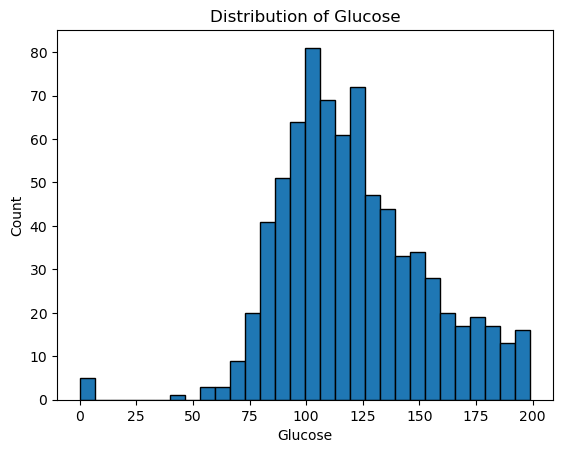

In [138]:
plt.figure() # Create a new figure object for the plot / 建立一個新的圖表物件

# Plot a histogram for the 'Glucose' column with 30 bins and a black edge color / 繪製 'Glucose' (血糖) 欄位的直方圖，分為 30 個區間，並加上黑色邊框
plt.hist(df['Glucose'], bins=30, edgecolor='black')

plt.title("Distribution of Glucose") # Set the title of the plot / 設定圖表標題
plt.xlabel("Glucose") # Set the label for the x-axis / 設定 X 軸的標籤
plt.ylabel("Count") # Set the label for the y-axis / 設定 Y 軸的標籤
plt.show() # Display the plot on the screen / 將圖表顯示在畫面上

Interpretation: Describe shape, center, spread, and any unusual features/outliers.

The distribution of Glucose is roughly normal and slightly right-skewed. The data is centered around a median of 110-120, with the majority of values spreading between 80 and 160. An unusual feature is the presence of outliers at 0, representing the miscoded missing values mentioned earlier.

### 3B. Histogram of BMI

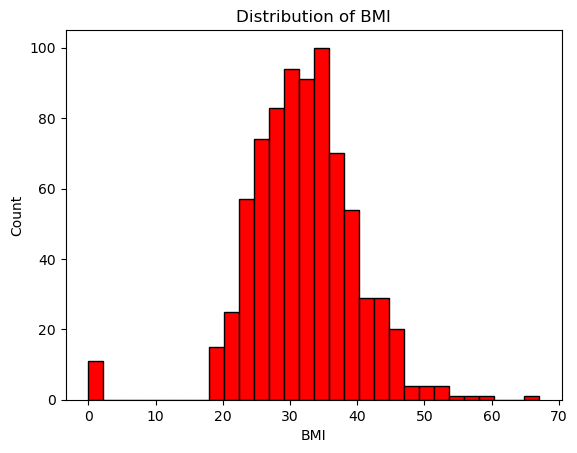

In [143]:
plt.figure() # Create a new figure object / 建立新的圖表物件

# Plot a histogram for 'BMI' with 30 bins, colored red, and a black edge color / 繪製 'BMI' 欄位的直方圖，分為 30 個區間，柱體填入紅色並加上黑色邊框
plt.hist(df['BMI'], bins=30, color='red', edgecolor='black')

plt.title("Distribution of BMI") # Set the title of the plot / 設定圖表標題
plt.xlabel("BMI") # Set the label for the x-axis / 設定 X 軸標籤
plt.ylabel("Count") # Set the label for the y-axis / 設定 Y 軸標籤
plt.show() # Display the plot / 顯示圖表

Interpretation: Describe shape, center, spread, and any unusual features/outliers.

The BMI distribution is visibly right-skewed with a long tail on the right. The center median is around 32, with most values spreading between 25 and 40. Similar to Glucose, there are suspicious outliers at 0, as well as a few extreme high values above 50.

### 3C. Boxplot: Glucose by Outcome

C:\Users\1109l\AppData\Local\Temp\ipykernel_20340\831887137.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot([g0, g1],


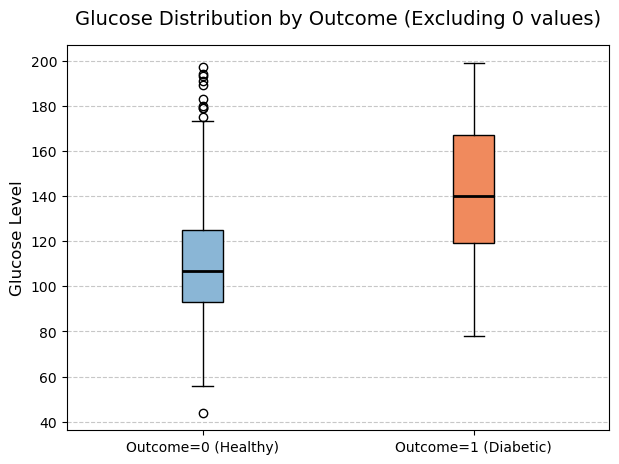

In [148]:
# 1. 篩選資料：不僅要分組，還要【剔除 Glucose 為 0 的異常值】
g0 = df[(df['Outcome'] == 0) & (df['Glucose'] > 0)]['Glucose']
g1 = df[(df['Outcome'] == 1) & (df['Glucose'] > 0)]['Glucose']

# 2. 建立圖表物件，並稍微放大圖表比例 (7x5) 讓細節更清楚
plt.figure(figsize=(7, 5)) 

# 3. 繪製箱型圖
# patch_artist=True 允許我們為箱子填色
# medianprops 加粗中位數的黑線，讓重點更突出
box = plt.boxplot([g0, g1], 
                  labels=["Outcome=0 (Healthy)", "Outcome=1 (Diabetic)"], 
                  patch_artist=True, 
                  medianprops={'color': 'black', 'linewidth': 2})

# 4. 為兩個箱子填上對比色 (淺藍與珊瑚橘)，增加視覺質感
colors = ['#8ab6d6', '#f08a5d']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# 5. 設定標題、標籤與輔助線
plt.title("Glucose Distribution by Outcome (Excluding 0 values)", fontsize=14, pad=15) 
plt.ylabel("Glucose Level", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7) # 加上 Y 軸水平格線，方便對齊看數值

plt.show() # 顯示圖表

Interpretation: Compare medians and variability. Do the groups appear separated?

The diabetic group (Outcome=1) has a significantly higher median Glucose level compared to the non-diabetic group (Outcome=0). The interquartile ranges (IQR) of the two groups are distinctly separated, suggesting a strong association between higher Glucose levels and the presence of diabetes.

### 3D. Scatter: Age vs BMI (by Outcome)

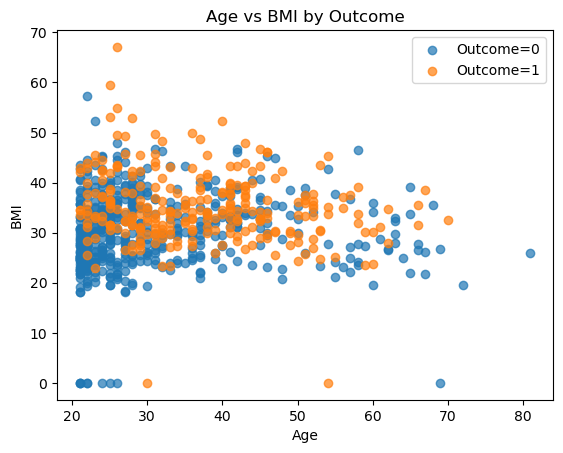

In [153]:
# Create a sub-dataframe containing only Outcome=0 records / 建立一個只包含 Outcome=0 (未患病) 資料的子資料表
df0 = df[df['Outcome'] == 0]
# Create a sub-dataframe containing only Outcome=1 records / 建立一個只包含 Outcome=1 (患病) 資料的子資料表
df1 = df[df['Outcome'] == 1]

plt.figure() # Create a new figure / 建立圖表物件

# Plot a scatter plot of Age vs BMI for Outcome=0, with 70% opacity and a legend label / 繪製未患病組的年齡對 BMI 散佈圖，設定 70% 透明度並加上圖例標籤
plt.scatter(df0['Age'], df0['BMI'], alpha=0.7, label="Outcome=0")
# Plot a scatter plot of Age vs BMI for Outcome=1, with 70% opacity and a legend label / 繪製患病組的年齡對 BMI 散佈圖，設定 70% 透明度並加上圖例標籤
plt.scatter(df1['Age'], df1['BMI'], alpha=0.7, label="Outcome=1")

plt.title("Age vs BMI by Outcome") # Set the title / 設定標題
plt.xlabel("Age") # Set x-axis label / 設定 X 軸標籤
plt.ylabel("BMI") # Set y-axis label / 設定 Y 軸標籤
plt.legend() # Display the legend on the plot / 在圖表上顯示圖例說明
plt.show() # Display the plot / 顯示圖表

Interpretation: Do you see clustering or separation between groups?

The data points mostly cluster in the 20-30 age range with a BMI between 25 and 40, showing no obvious overall linear trend between Age and BMI. However, points representing the diabetic group (Outcome=1) tend to fall more frequently in the region of older age and higher BMI.

## 4. Group Comparison Summary (Descriptive)

TO DO:
1) Compute group means for Glucose, BMI, Age by Outcome  
2) Compute mean differences (Outcome=1 minus Outcome=0)  


In [158]:
# Group the data by 'Outcome' and calculate the mean for 'Glucose', 'BMI', and 'Age' / 依照 'Outcome' (是否患病) 將資料分組，並計算 'Glucose'、'BMI' 和 'Age' 的平均值
summary_means = df.groupby('Outcome')[['Glucose', 'BMI', 'Age']].mean()
summary_means # Display the calculated means table / 顯示計算出來的平均值表格

,Glucose,BMI,Age
Outcome,,,
0,109.980000,30.304200,31.190000
1,141.257463,35.142537,37.067164


In [160]:
# Subtract the mean values of Outcome=0 from Outcome=1 to find the absolute difference / 將患病組 (Outcome=1) 的平均值減去未患病組 (Outcome=0) 的平均值，以得出兩組差異
mean_diff = summary_means.loc[1] - summary_means.loc[0]
mean_diff # Display the differences / 顯示計算出來的差異數值

Glucose    31.277463
BMI         4.838337
Age         5.877164
dtype: float64

Interpretation (5–8 lines):
- Which variables show the biggest differences between Outcome groups?
- Which 1–2 variables look most promising as “associated with Outcome” (based on descriptive evidence)?
- Be cautious: do not claim causality.


Between the two Outcome groups, Glucose shows the biggest absolute difference, with the mean of the diabetic group being approximately 31.28 higher than the non-diabetic group. Based on this descriptive evidence, Glucose and BMI appear to be the most promising variables associated with Outcome, as their means are notably higher in the diabetic group. However, it is important to be cautious: this observed statistical association does not imply a direct causality, and further rigorous inferential testing is required to confirm any true clinical relationships.

## 5. Sampling Simulation (Concept Preparation)

Goal: understand sampling variability of the sample mean.

TO DO:
1) Sample n = 30 observations (with replacement)  
2) Compute the sample mean of Glucose  
3) Repeat B = 1000 times  
4) Plot the distribution of sample means (matplotlib)  
5) Report the mean and standard deviation of the sampling distribution  


In [165]:
# Set the number of bootstrap iterations to 1000 / 設定拔靴法 (Bootstrap) 重複抽樣的次數為 1000 次
B = 1000
# Set the sample size for each iteration to 30 / 設定每次抽樣的樣本數大小為 30
n = 30

In [167]:
means = [] # Initialize an empty list to store the sample means / 建立一個空串列

# Loop 1000 times to perform the sampling simulation
for b in range(B):
    # 【關鍵修正】使用 df['Glucose'] > 0 來排除不合理的 0 值，而不是用 dropna()
    sample = df[df['Glucose'] > 0]['Glucose'].sample(n=n, replace=True) 
    
    # Calculate the mean of the current sample
    m = sample.mean()
    means.append(m)

# Convert to numpy array
means = np.array(means)

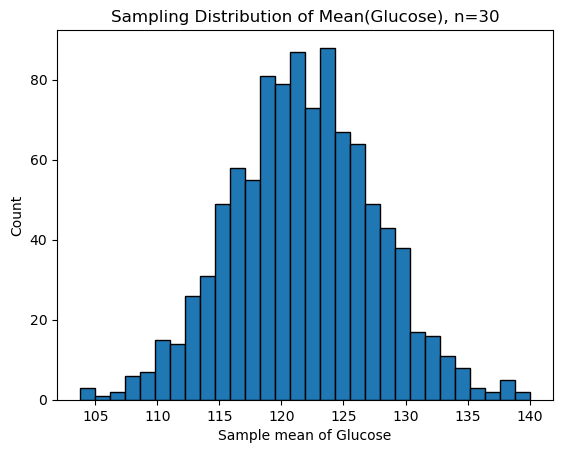

In [168]:
plt.figure() # Create a new figure / 建立圖表物件

# Plot a histogram of the 1000 simulated sample means with 30 bins and a black edge / 繪製這 1000 個模擬樣本平均數的直方圖，分為 30 個區間並加上黑框
plt.hist(means, bins=30, edgecolor='black')

plt.title("Sampling Distribution of Mean(Glucose), n=30") # Set title / 設定標題
plt.xlabel("Sample mean of Glucose") # Set x-axis label / 設定 X 軸標籤
plt.ylabel("Count") # Set y-axis label / 設定 Y 軸標籤
plt.show() # Display the plot / 顯示圖表

In [169]:
# Calculate the center (mean) of the sampling distribution / 計算這群抽樣分佈資料的中心點 (總平均數)
center = means.mean()
# Calculate the spread (sample standard deviation, ddof=1) of the sampling distribution / 計算這群抽樣分佈資料的擴散程度 (樣本標準差，自由度設為 1)
spread = means.std(ddof=1)
center, spread # Display both the center and the spread values / 同時顯示中心點與擴散程度的數值

(121.76060000000001, 5.8173637045987325)

Interpretation (5–8 lines):
- What does the sampling distribution represent?
- Is it narrower than the raw Glucose distribution? Why?
- How does this connect to uncertainty of an estimate?


The sampling distribution represents the distribution of sample means calculated from 1000 repeated random samples (n=30). According to the Central Limit Theorem, this distribution is approximately normal. Notably, it is much narrower than the raw Glucose distribution. This is because the standard deviation of the sampling distribution (Standard Error) equals the population standard deviation divided by the square root of n, which shrinks the spread. This narrow spread directly reduces the uncertainty of our estimate, proving that taking a sample mean gives us a highly reliable approximation of the true population parameter.

## Week B Consultation Checklist (Must Be Completed Before Consultation)

Before Week B, your group must have a **runnable draft** that includes:

1) Sections 1–5 completed (code runs without errors)  
2) All required plots (3A–3D) displayed correctly  
3) Group summary table (Section 4) + a short conclusion paragraph  
4) Sampling simulation completed (Section 5) + interpretation  
5) A proposed extension idea for Week C (next section)

No runnable draft → no Week B consultation mark.


## 6. Week C Extension

Choose **one** extension direction. The extension should add insight beyond the required analysis.

Examples (choose one):
- Correlation analysis (heatmap or top correlations with Outcome)
- Compare medians instead of means (robustness)
- Create age groups and compare outcomes across age bins
- Create BMI categories and compare outcome rates
- Another visualization (density, pairwise, etc.)

Write your plan first, then implement below.


### 6A. Extension Plan (5–8 lines)
TO DO: Write your plan here.

We plan to use the seaborn library to generate a Correlation Heatmap for all 8 features in the dataset. While our previous analysis focused only on Glucose, BMI, and Age against the Outcome, a heatmap allows us to visualize the relationships between all variables simultaneously. Our goal is to verify which feature has the strongest correlation with diabetes (Outcome) and to discover hidden multicollinearity or physiological links between the independent variables themselves (e.g., Age vs. Pregnancies, or SkinThickness vs. BMI).

### 6B. Extension Implementation (code + outputs)

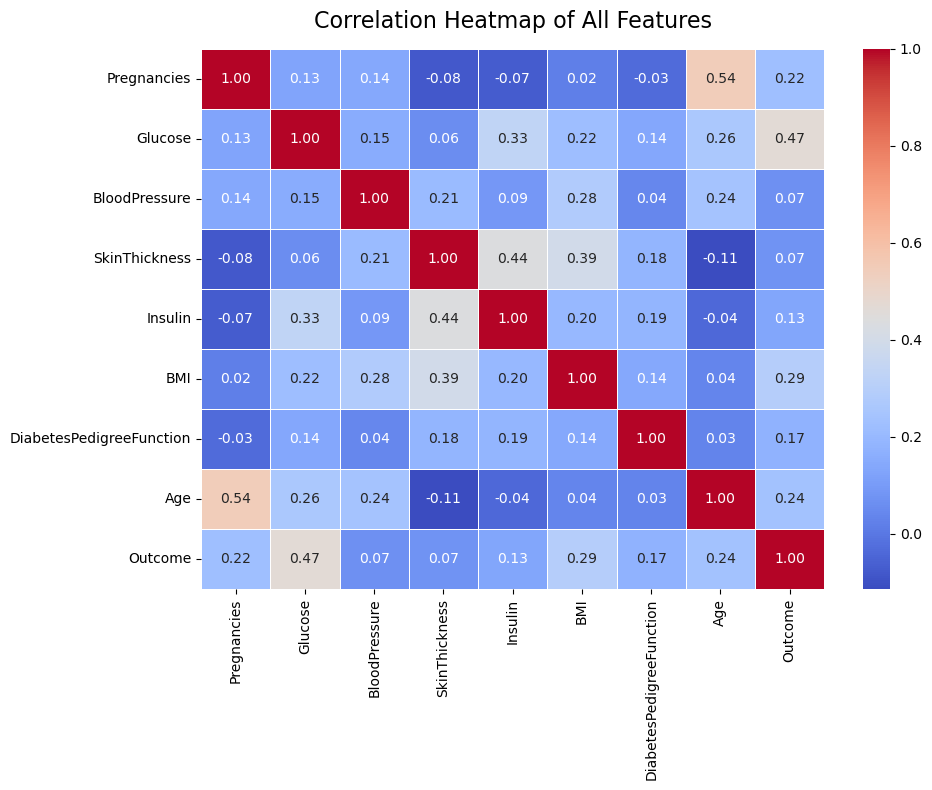

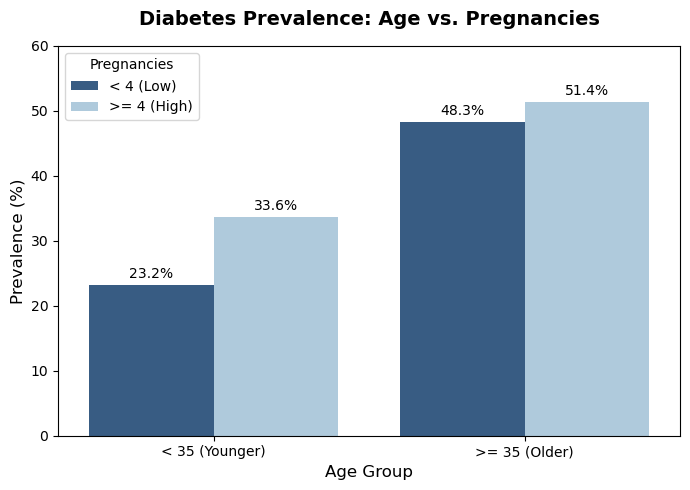

In [180]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 讀取資料集檔案
df = pd.read_csv("Diabetes.csv")

# ==========================================
# Extension Part 1: Correlation Heatmap
# ==========================================
corr_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of All Features', fontsize=16, pad=15)
plt.tight_layout()
plt.show()

# ==========================================
# Extension Part 2: Cross Bar Chart (Age vs Pregnancies)
# To decode the high correlation (0.54) found in the heatmap
# ==========================================
df['Age_Group'] = df['Age'].apply(lambda x: '>= 35 (Older)' if x >= 35 else '< 35 (Younger)')
df['Preg_Group'] = df['Pregnancies'].apply(lambda x: '>= 4 (High)' if x >= 4 else '< 4 (Low)')

pivot = df.groupby(['Age_Group', 'Preg_Group'])['Outcome'].mean().reset_index()
pivot['Prevalence (%)'] = (pivot['Outcome'] * 100).round(1)

plt.figure(figsize=(7, 5))
sns.barplot(data=pivot, x='Age_Group', y='Prevalence (%)', hue='Preg_Group', palette=['#2b5c8f', '#a8cce3'])
plt.title('Diabetes Prevalence: Age vs. Pregnancies', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Prevalence (%)', fontsize=12)
plt.ylim(0, 60)
plt.legend(title='Pregnancies', loc='upper left')

for p in plt.gca().patches:
    height = p.get_height()
    if height > 0:
        plt.gca().annotate(f'{height:.1f}%', (p.get_x() + p.get_width() / 2., height), 
                           ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 3), textcoords='offset points')
plt.tight_layout()
plt.show()

### 6C. Extension Interpretation (5–8 lines)
TO DO: Interpret what your extension shows and how it supports/changes your conclusions.

Based on our extension analysis (Heatmap & Bar Chart), we found two critical insights:

1) Strongest Predictor & Hidden Collinearity: The heatmap confirms Glucose is the strongest predictor (r=0.47). Moreover, it reveals a high correlation (r=0.54) between Age and Pregnancies, suggesting a multicollinearity risk.

2) Dispelling the Myth: To investigate this 0.54 correlation, we created a segmented bar chart. It clearly shows that once a patient crosses the age of 35, the diabetes prevalence spikes to ~50% regardless of pregnancy count. This proves that Age is the overwhelming core risk factor, heavily diluting the impact of pregnancies in older demographics.

## 7. Week C Exhibition Reflection (After Rotations)

After you visit other groups during Week C, write at least **three** items:

1) One interesting analysis/visualization idea you saw  
2) One interpretation insight that was better than yours (what and why)  
3) One improvement you would apply to your own workflow next time  


Reflection notes:

1) One interesting analysis idea I saw was how another group handled the missing data (the biologically impossible '0' values). Instead of just dropping these invalid rows like we did, they used data imputation techniques to fill in and estimate the missing values. I thought this was a very impressive way to preserve the dataset's size and integrity.

2) Our group focused on comparing whether "Age" or "Pregnancies" had a stronger correlation with diabetes by using a binary split at age 35. However, I found another group's insight better because they binned the "Age" variable into several distinct age groups to study its positive correlation with diabetes prevalence. This granular approach is better because it clearly shows how the risk progressively scales across different life stages, offering a more detailed perspective than our simple binary split.

3) Next time, I would reference other groups' data preprocessing methods, particularly how they organized and cleaned the raw data. By adopting more advanced data preparation techniques (like filling in missing values instead of removing them), we can retain more data points, which would make our final analysis and future predictive models much more accurate.
